In [1]:
import numpy as np
from ScanImageTiffReader import ScanImageTiffReader
import napari
import pickle

In [2]:
from skimage import data
from scipy import stats
from scipy import signal
from tifffile import tifffile
from os.path import sep
from matplotlib import pyplot as plt
import math
import matplotlib.colors as colors
import xarray as xr
import pandas as pd
import seaborn as sns
import json
import os
from scipy.ndimage import gaussian_filter1d

In [3]:
import SessionTools.two_photon as st2p
from fly2p_function_TQ.imaging_2p_preprocessing import combine_single_tiff, computeMotionShift, motionCorrection, low_pass_filter_TQ, high_pass_filter_TQ, averaging_frame, combine_single_tiff_ch1
from fly2p_function_TQ.imaging_2p_preprocessing import combine_PB_corresponding_ROI,get_raw_F,get_dff_array, normalizing_dff_array, combine_single_tiff_V2, combine_EB_corresponding_ROI,get_dff_array_running
from fly2p_function_TQ.imaging_2p_PVA_functions import PVA_radian_calcul, PVAangleToRoi, PVA_radian_to_angle, PVA_angle_to_radian, calcualteBumpAmplitude
from fly2p_function_TQ.imaging_2p_fictrac_imaging_alignment import downsample_heading_to_total_volume, offset_calculation,fictrack_signal_decoding,moving_wrapped_plot_by_offset
from fly2p_function_TQ.imaging_2p_fixed_heading_period_analysis import find_stop_period_on_heading

In [4]:
# Some key parameters for imaging analysis (for futuure should come from direct reading of metadata file)
volume_cycle = 2407
volume_time = 0.10388
volume_rate = 1/volume_time
slice_per_volume = 8
fictrack_sampling_rate = 50000

# 1 for cl, 0 for dark trial
trial_type = 0

# 1 for PB
brain_region = 0

In [5]:
green = 1
red = 0

In [6]:
time_array_imaging = np.arange(volume_cycle)/volume_rate

In [7]:
if green == 1:
    image_data_combined, tiff_file_sequence = combine_single_tiff(slice_num = slice_per_volume, cycle_num = volume_cycle, file_dir = '/home/tianhaoqiu/Desktop/TQfly784-002')
    image = image_data_combined

if red == 1:
    image_data_combined_red, tiff_file_sequence_red = combine_single_tiff_ch1(slice_num = slice_per_volume, cycle_num = volume_cycle, file_dir = '/home/tianhaoqiu/Desktop/Pilot ASAP5/TQfly142-002')
    image_red = image_data_combined_red
image.shape

(2407, 8, 174, 508)

In [8]:
if green == 1:
    imgStack = xr.DataArray(image,dims = ['volumes [s]', 'planes [µm]', 'xpix [µm]', 'ypix [µm]'])
if red == 1:
    imgStack_red = xr.DataArray(image_red,dims = ['volumes [s]', 'planes [µm]', 'xpix [µm]', 'ypix [µm]'])

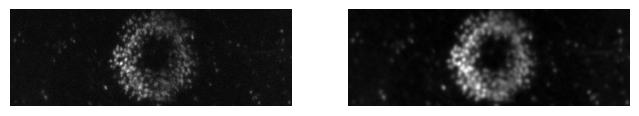

In [9]:
## Motion Correction setup
# Set reference image
stackMP = np.max(imgStack, axis=1) # max projection over volume
# Generate reference image
reference_num = np.int_(np.round(0.1 * volume_cycle))
refImg = np.mean(stackMP[0:reference_num,:,:],axis=0)

from scipy.ndimage import gaussian_filter
refImgFilt = gaussian_filter(refImg, sigma=2)

fig, axs = plt.subplots(1,2,figsize=(8,4))
axs[0].imshow(refImg,cmap='Greys_r', origin='lower'); axs[0].axis('off');
axs[1].imshow(refImgFilt,cmap='Greys_r', origin='lower'); axs[1].axis('off');

In [10]:
if red == 1:
    ## Motion Correction setup
    # Set reference image
    stackMP_red = np.max(imgStack_red, axis=1) # max projection over volume
    # Generate reference image
    reference_num = np.int_(np.round(0.1 * volume_cycle))
    refImg_red = np.mean(stackMP_red[0:reference_num,:,:],axis=0)

    from scipy.ndimage import gaussian_filter 
    refImgFilt_red = gaussian_filter(refImg_red, sigma=2)

    fig, axs = plt.subplots(1,2,figsize=(8,4))
    axs[0].imshow(refImg_red,cmap='Greys_r', origin='lower'); axs[0].axis('off');
    axs[1].imshow(refImgFilt_red,cmap='Greys_r', origin='lower'); axs[1].axis('off');

perform motion correction on a single plane/max projection


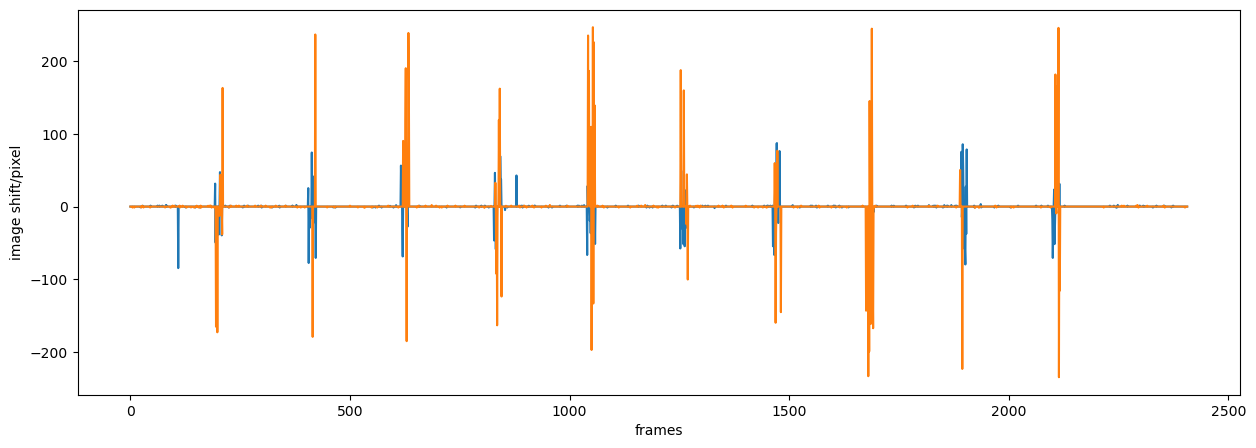

In [11]:
shift = computeMotionShift(stackMP, refImg, 10, 2, doFilter=False, stdFactor=4, showShiftFig=True)

In [12]:
if red == 1:
    shift_red = computeMotionShift(stackMP_red, refImg_red, 10, 2, doFilter=False, stdFactor=4, showShiftFig=True)

In [13]:
stack4dMC = motionCorrection(imgStack, shift)

In [14]:
if red == 1:
    stack4dMC_red = motionCorrection(imgStack_red, shift_red)

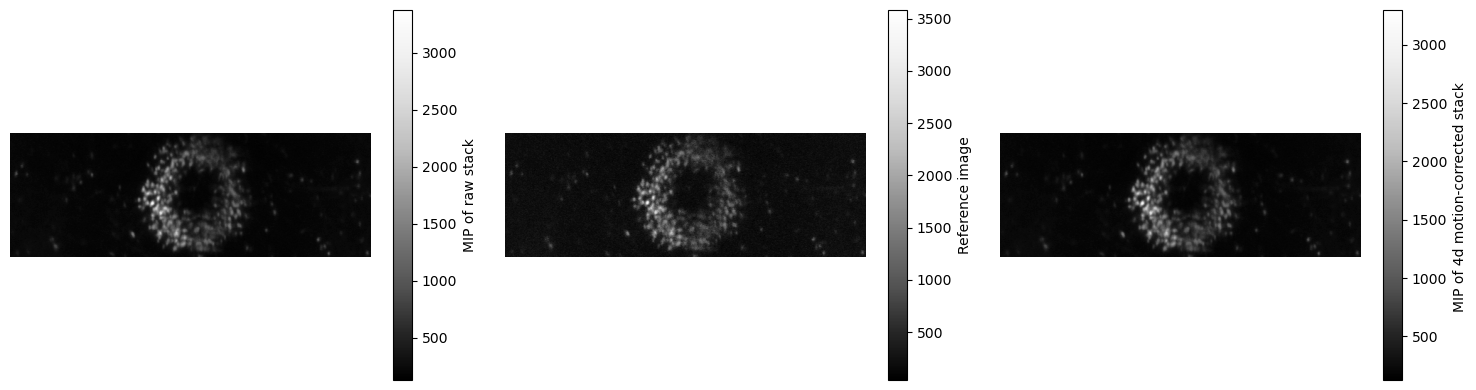

In [15]:
fig, axs = plt.subplots(1,3,figsize=(15,4))
cb = axs[0].imshow(imgStack.max(axis=1).mean(axis=0),cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[0], label='MIP of raw stack')
axs[0].axis('off');
cb = axs[1].imshow(refImg,cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[1], label='Reference image')
axs[1].axis('off');
cb = axs[2].imshow(stack4dMC.max(axis=1).mean(axis=0),cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[2], label='MIP of 4d motion-corrected stack ')
axs[2].axis('off');
fig.tight_layout()

In [16]:
if red == 1:
    imgStack_napari_red = np.expand_dims(imgStack_red, axis =0)
if green == 1:
    #stack4dMCTEST = np.expand_dims(stack4dMC, axis =0)
    imgStack_napari = np.expand_dims(imgStack, axis =0)

In [17]:
# Use this for EB roi
if brain_region == 0:
    ebnapari = st2p.preprocessing.napari_tools.EllipsoidBodySession().new_session(imgStack_napari.mean(axis=1))
# Use this for PB roi
else:
    viewer = napari.Viewer()
    new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #viewer.dims.ndisplay = 3

In [18]:
if brain_region == 0:
    ebnapari.make_phase_masks()

In [18]:
label = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker/TQfly784/ROI_1_TQfly784-002.tif")
label_background = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker/TQfly784/ROI_1_TQfly784-002_background.tif")
if red == 1:
    label_red = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/delta7_ASAP5/napari_ROI_TQfly142/ROI_1_TQfly142_002_red.tif")
#viewer.add_labels(label, name='Labels_16_Roi'

In [19]:
#Load ROI and label from napari
#napari_roi_16 = viewer.layers['Labels_16_Roi'].data
if brain_region == 0: 
    napari_roi = label    
    napari_roi_background = label_background 
else:
    #napari_roi = label[0,:,:,:]
    #Start from TQfly081, easier way to save ROI
    napari_roi = np.squeeze(label , axis=0) 
    napari_roi_background = np.squeeze(label_background , axis=0) 
    if red == 1:
        napari_roi_red = np.squeeze(label_red , axis=0) 

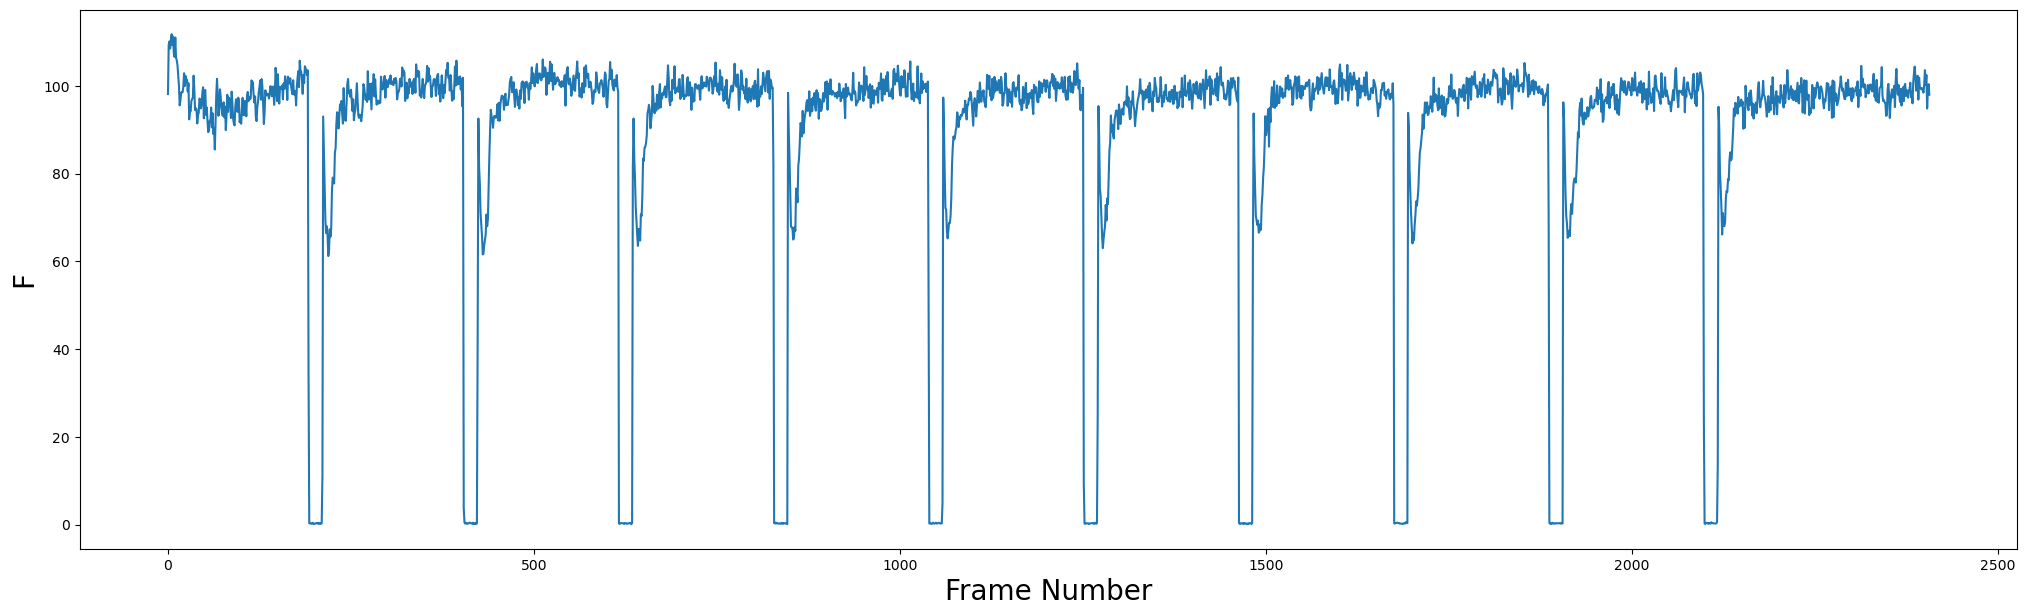

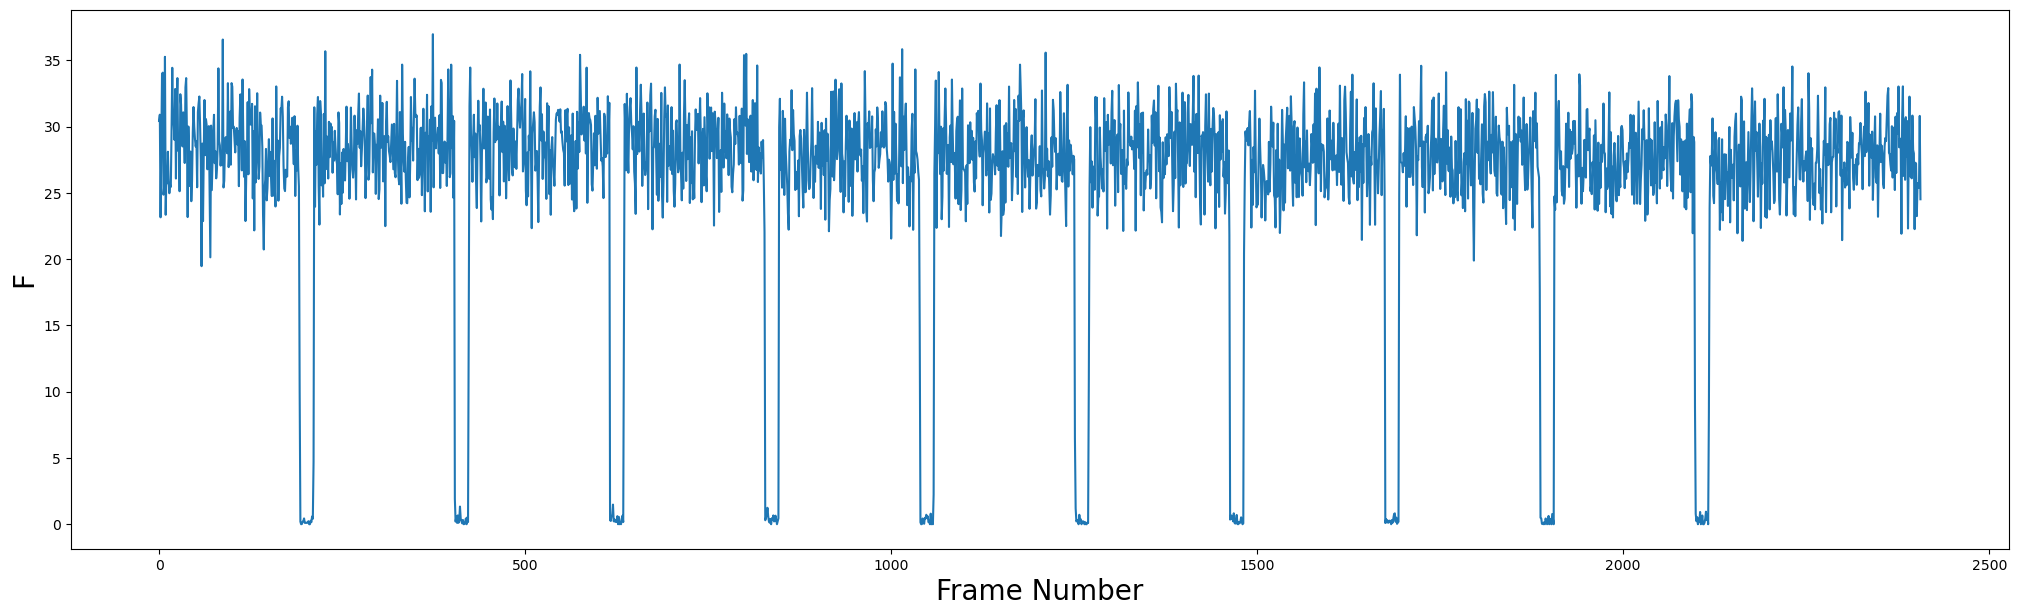

In [20]:
ROI_total = 1
F_array = get_raw_F(ROI_total, napari_roi, imgStack)
F_array_background = get_raw_F(ROI_total, napari_roi_background, imgStack)
if red == 1:
    F_array_red = get_raw_F(ROI_total, napari_roi_red, imgStack_red)

In [21]:
# Define parameters
thresholds = np.percentile(F_array, 11, axis=0)  # Compute separate threshold per ROI (3th percentile)
min_duration = 19# Minimum number of frames for a valid stimulation period
start_frame = 100  # Ignore the first 100 frames before detecting stimulation

# Step 1: Detect low-signal frames per ROI
low_signal_per_roi = F_array < thresholds  # Boolean mask: True where signal is below threshold

# Step 2: Identify frames where **any** ROI detects a stimulation period
low_signal_any = np.any(low_signal_per_roi, axis=1)  # If any ROI marks this frame, it's a stim frame

# Step 3: Find contiguous low-signal periods **starting from frame 100**
stimulation_periods = []
current_start = None

for i in range(start_frame, len(low_signal_any)):  # Start from frame 100
    if low_signal_any[i]:  # If any ROI classifies this frame as stim
        if current_start is None:
            current_start = i  # Mark the start of a stimulation period
    else:
        if current_start is not None:
            # Check if the stim period is long enough
            if i - current_start >= min_duration:
                stimulation_periods.append((current_start, i - 1))
            current_start = None  # Reset

# Handle the last stimulation period if it extends until the end
if current_start is not None and len(low_signal_any) - current_start >= min_duration:
    stimulation_periods.append((current_start, len(low_signal_any) - 1))

# Print results
print("Detected Stimulation Periods (starting from frame 100):", stimulation_periods)

Detected Stimulation Periods (starting from frame 100): [(192, 211), (404, 423), (616, 634), (828, 846), (1039, 1058), (1251, 1270), (1463, 1482), (1675, 1693), (1886, 1905), (2098, 2117)]


In [22]:
# Step 1: Create a mask for removal
frames_to_keep = np.ones(F_array.shape[0], dtype=bool)  # Keep all frames initially

for start, end in stimulation_periods:
    frames_to_keep[start:end+1] = False  # Mark stimulation frames as False (to be removed)


# Step 2: Apply mask to remove stimulation frames
F_array_stimulation_period_removed = F_array[frames_to_keep]

# Step 3: Find correct post-stimulation indices in `filtered_data`
stimulation_durations = np.zeros(len(stimulation_periods))
for i in range(len(stimulation_periods)):
    stimulation_durations[i] = stimulation_periods[i][1] - stimulation_periods[i][0] + 1

cut_indices = np.zeros(len(stimulation_periods))
for j in range(len(stimulation_periods)):
    cut_indices[j] = (stimulation_periods[j][1] + 1) - (np.sum(stimulation_durations[0:(j+1)]))
cut_indices = cut_indices.astype(int)

# Step 4: Print results
print("Original shape:", F_array.shape)
print("F_array_stimulation_period_removed :", F_array_stimulation_period_removed .shape)
print("Cut indices (in F_array_stimulation_period_removed ):", cut_indices)

Original shape: (2407, 1)
F_array_stimulation_period_removed : (2210, 1)
Cut indices (in F_array_stimulation_period_removed ): [ 192  384  576  769  961 1153 1345 1537 1729 1921]


In [23]:
# Step 1: Create a mask for removal
frames_to_keep = np.ones(F_array_background.shape[0], dtype=bool)  # Keep all frames initially

for start, end in stimulation_periods:
    frames_to_keep[start:end+1] = False  # Mark stimulation frames as False (to be removed)


# Step 2: Apply mask to remove stimulation frames
F_array_background_stimulation_period_removed = F_array_background[frames_to_keep]

# Step 3: Find correct post-stimulation indices in `filtered_data`
stimulation_durations = np.zeros(len(stimulation_periods))
for i in range(len(stimulation_periods)):
    stimulation_durations[i] = stimulation_periods[i][1] - stimulation_periods[i][0] + 1

cut_indices = np.zeros(len(stimulation_periods))
for j in range(len(stimulation_periods)):
    cut_indices[j] = (stimulation_periods[j][1] + 1) - (np.sum(stimulation_durations[0:(j+1)]))
cut_indices = cut_indices.astype(int)

# Step 4: Print results
print("Original shape:", F_array_background.shape)
print("F_array_stimulation_period_removed :", F_array_background_stimulation_period_removed.shape)
print("Cut indices (in F_array_stimulation_period_removed ):", cut_indices)

Original shape: (2407, 1)
F_array_stimulation_period_removed : (2210, 1)
Cut indices (in F_array_stimulation_period_removed ): [ 192  384  576  769  961 1153 1345 1537 1729 1921]


In [24]:
volume_cycle_new = len(F_array_stimulation_period_removed )
time_array_imaging = np.arange(volume_cycle_new)/volume_rate

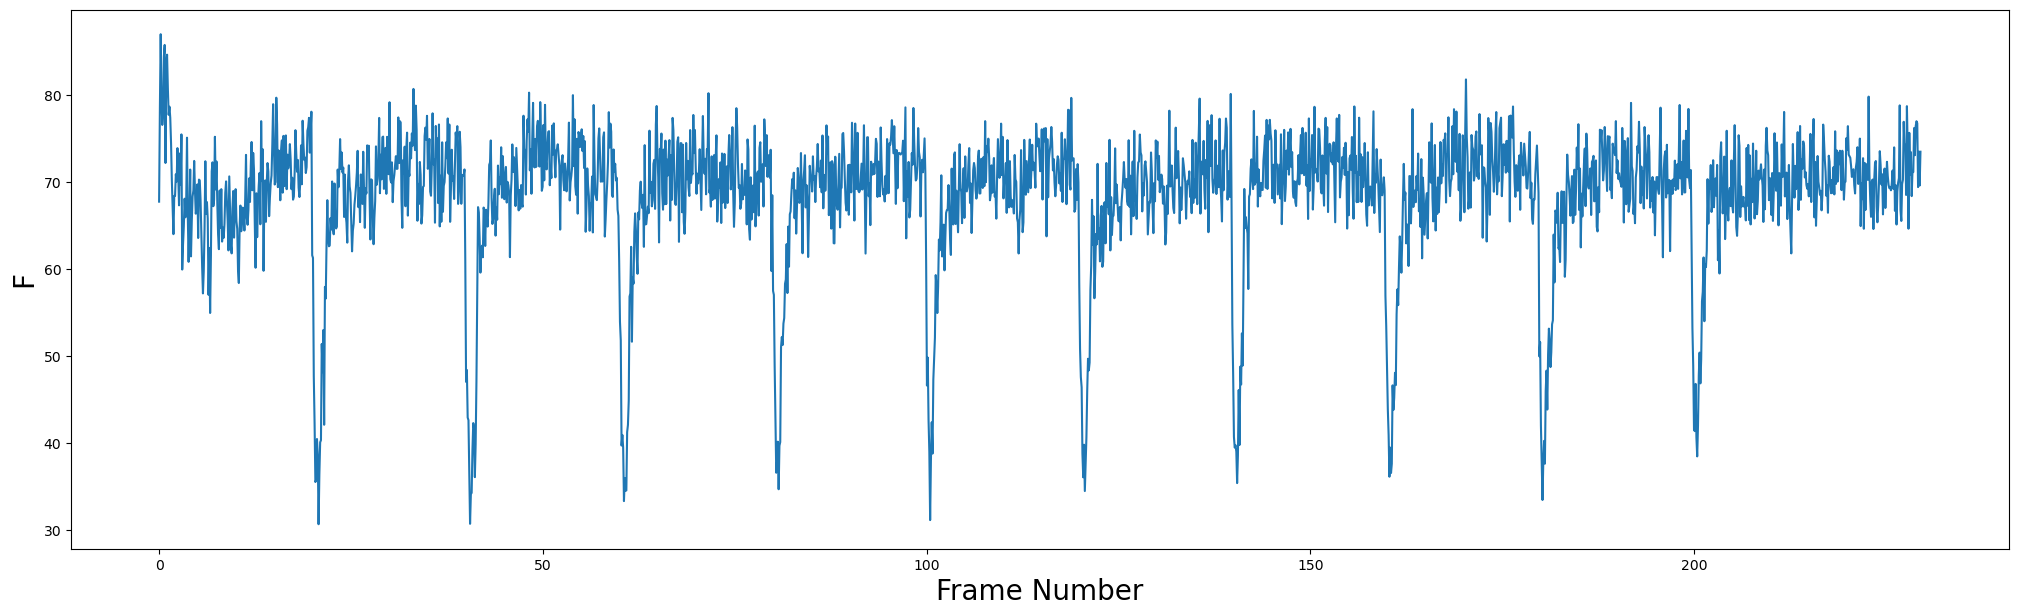

In [25]:
F_array_bg_subtracted = F_array_stimulation_period_removed - F_array_background_stimulation_period_removed
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging, F_array_bg_subtracted)
plt.ylabel('F',fontsize=20)
plt.xlabel('Frame Number', fontsize=20)
plt.show()

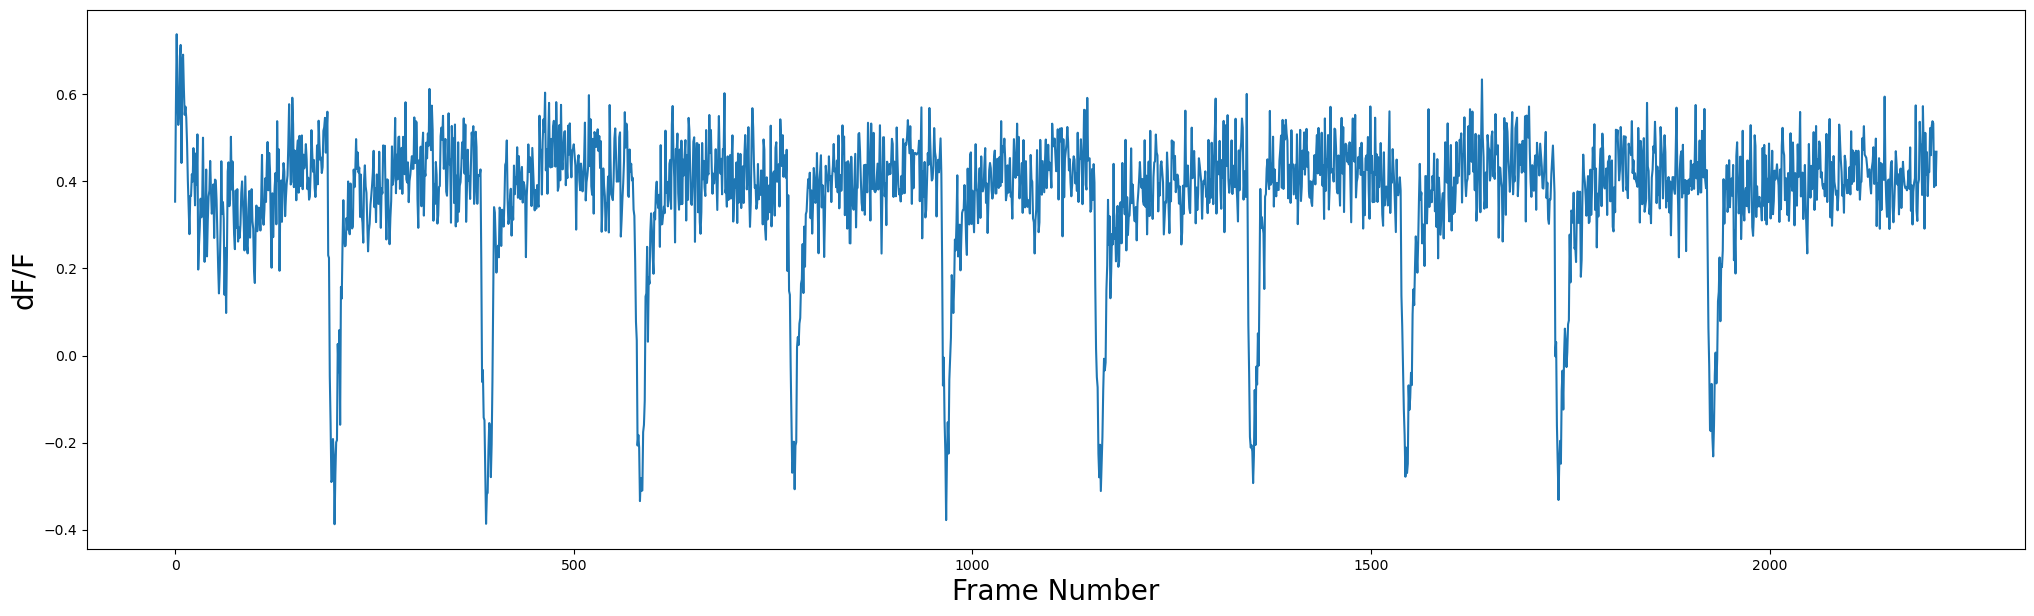

In [26]:
dF_F_array = get_dff_array(raw_F_array = F_array_bg_subtracted, ROI_num = ROI_total, F_zero_cutoff = 0.05, if_plot= 1)
if red == 1:
    dF_F_array_red = get_dff_array(raw_F_array = F_array_red, ROI_num = ROI_total, F_zero_cutoff = 0.05,if_plot= 1)

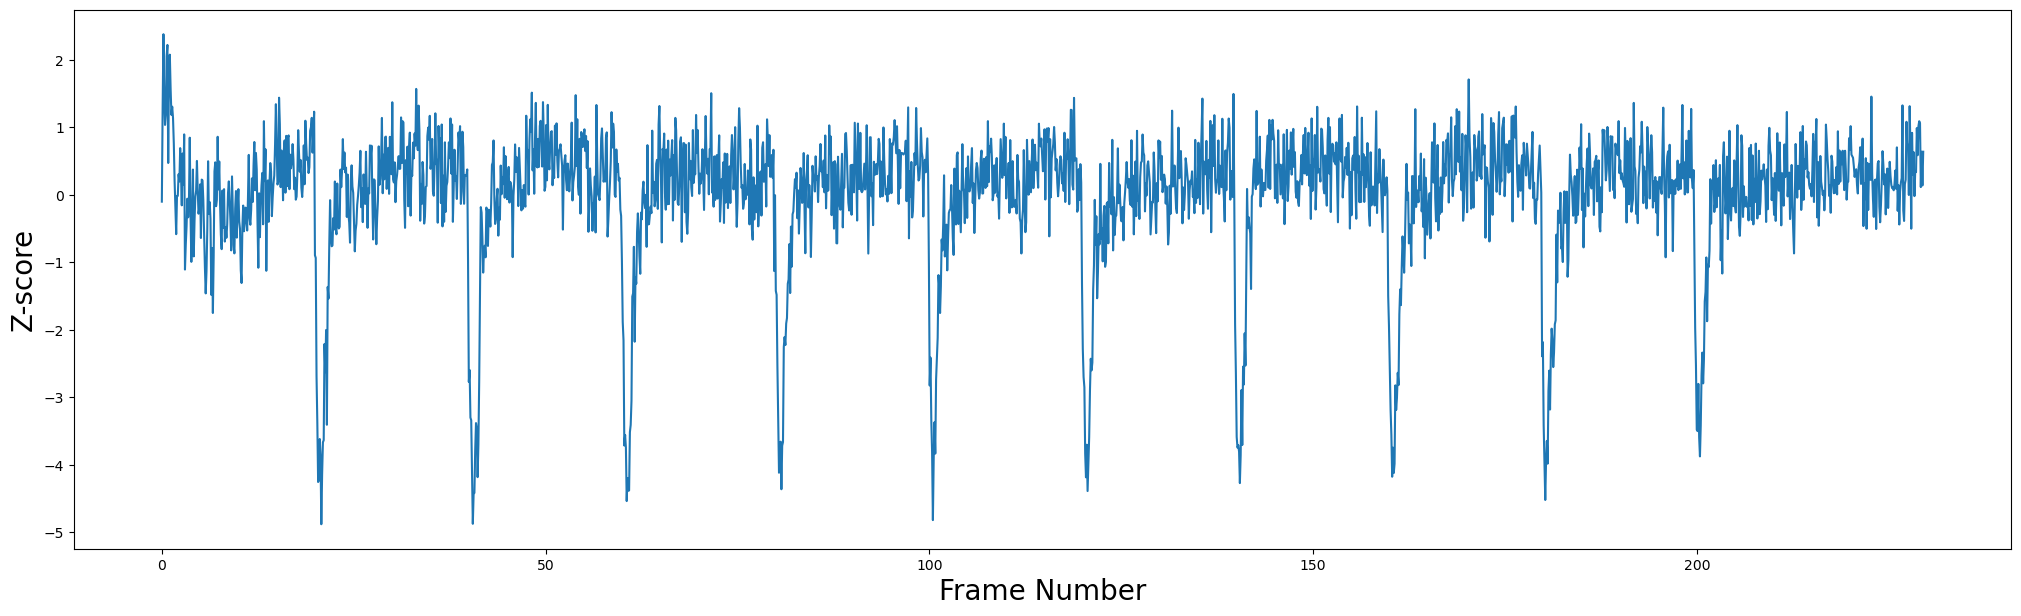

In [27]:
# Z-score: alternative way to calculate df/f
Z_score_array = np.zeros((F_array_bg_subtracted.size, ROI_total))
F_sd = np.std(F_array_bg_subtracted, axis = 0)
F_mean = np.mean(F_array_bg_subtracted, axis = 0)
for z_index in range(ROI_total):
    Z_score_array [:,z_index] = (F_array_bg_subtracted[:,z_index] - F_mean[z_index])/F_sd[z_index]

plt.figure(figsize= (25,7))
plt.plot(time_array_imaging, Z_score_array)
plt.ylabel('Z-score',fontsize=20)
plt.xlabel('Frame Number', fontsize=20)
plt.show()

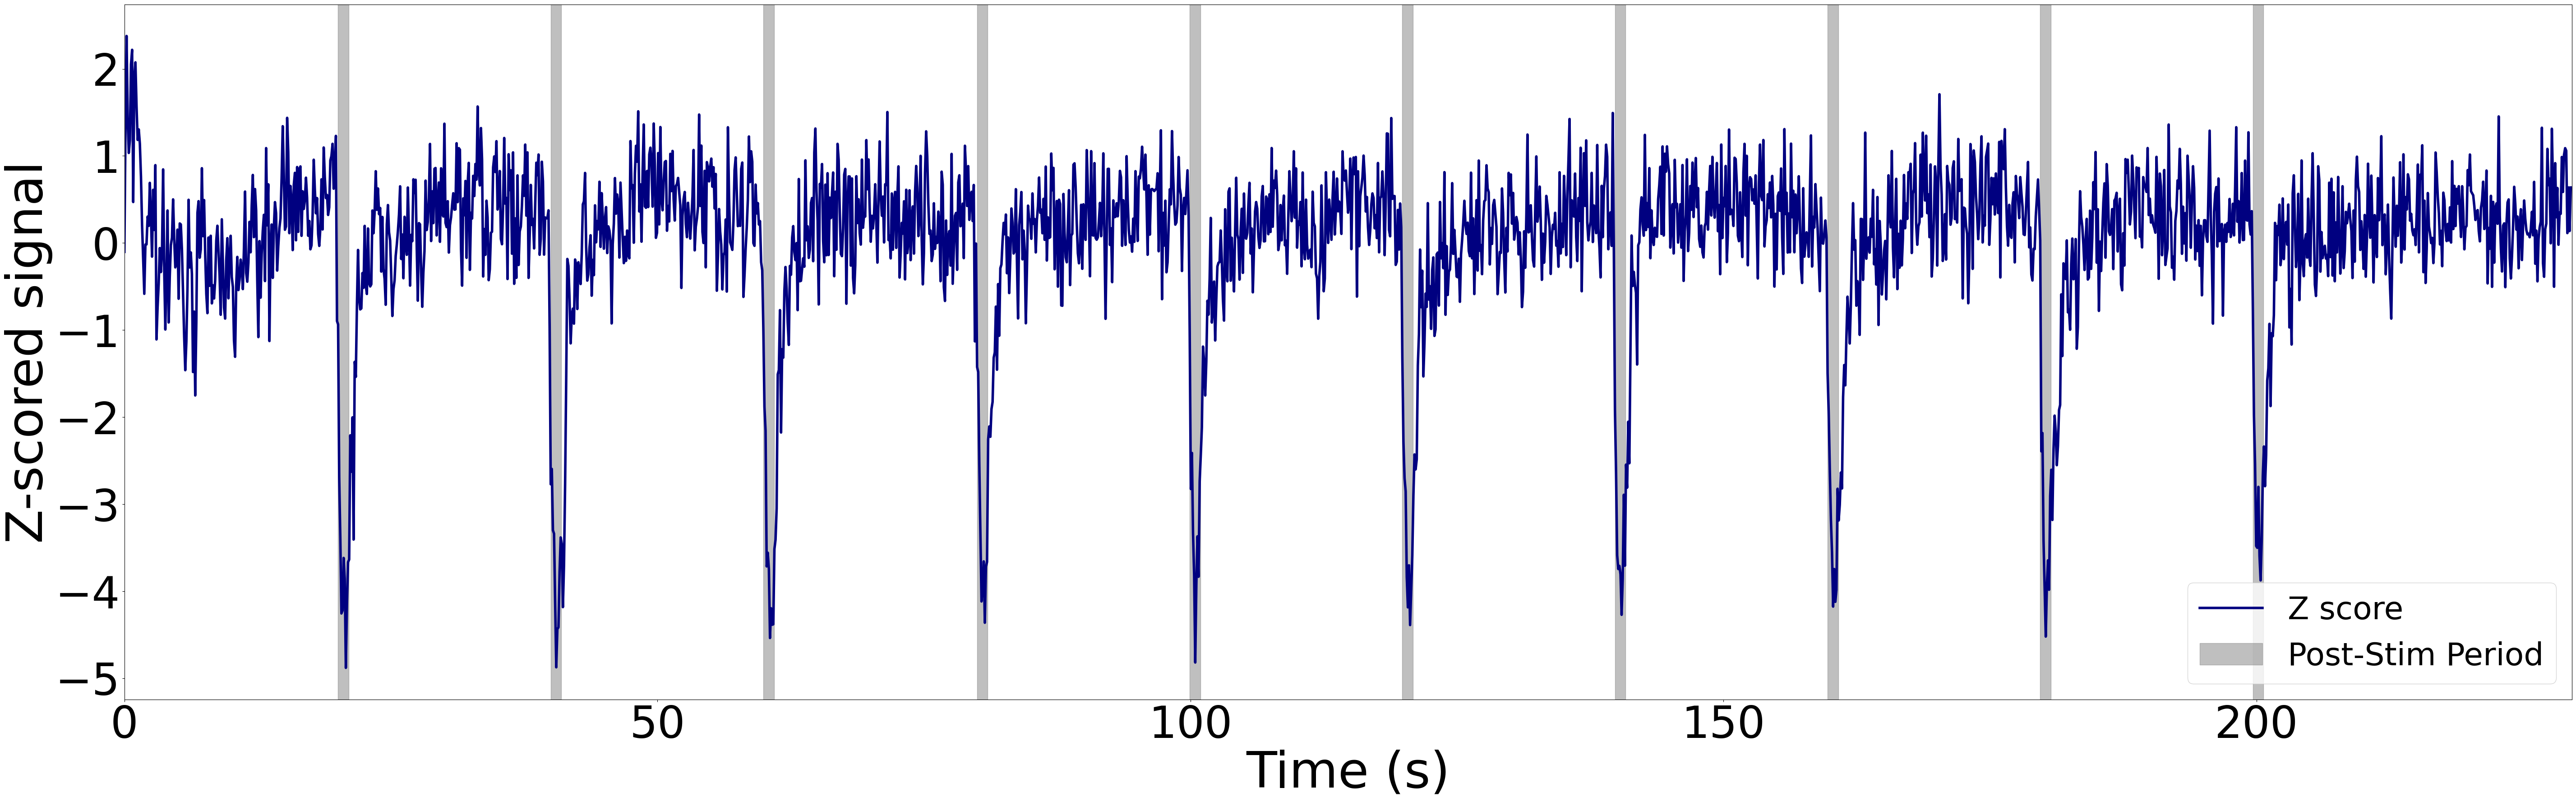

In [28]:
# Create the figure
plt.figure(figsize=(70, 20))

# Plot bump width
plt.plot(time_array_imaging, Z_score_array, linewidth=4, color='navy', label="Z score")

# Step 1: Add shaded rectangles after post-stim indices (cut_indices)
for cut in cut_indices:
    start_time = (cut+1) * volume_time  
    end_time = start_time + 1

    plt.axvspan(start_time, end_time, color='gray', alpha=0.5, label="Post-Stim Period" if cut == cut_indices[0] else "")

# Labels and axes formatting
plt.xlabel('Time (s)', fontsize=80)
plt.ylabel('Z-scored signal', fontsize=80)
plt.xticks(fontsize=70)
plt.yticks(fontsize=70)
plt.xlim(0, volume_cycle_new * volume_time)
plt.legend(fontsize=50)
plt.show()


In [29]:
import numpy as np

def compute_sta_around_cuts(
    signal,                # 1D array over time (or 2D T×R if you pass per-ROI; we'll reduce to amplitude)
    cut_indices,           # iterable of integer frame indices for the *cut* (we align to cut+1 like your span)
    volume_time,           # seconds per frame
    pre_s=1.0,             # window before (s)
    post_s=1.0,            # window after (s)
    align_to_next=True,    # True -> center at cut+1 (matches start_time=(cut+1)*volume_time in your code)
    baseline=None          # None | 'pre-sub' (subtract mean of pre window) | 'pre-div' (divide by |pre| mean)
):
    """
    Returns: dict with keys 'time', 'sta_mean', 'sta_sem', 'n_trials', 'epochs'
    """
    sig = np.asarray(signal)

    # If a 2D T×R array was given, convert to a single amplitude trace (range across ROIs).
    if sig.ndim == 2:
        sig = np.ptp(sig, axis=1)  # peak-to-peak across ROIs per frame

    sig = sig.astype(float).ravel()
    T = sig.size
    fps = 1.0 / float(volume_time)

    pre_f  = int(round(pre_s  * fps))
    post_f = int(round(post_s * fps))
    offsets = np.arange(-pre_f, post_f + 1, dtype=int)   # relative indices; includes time 0
    t_rel = offsets * volume_time

    epochs = []
    for cut in cut_indices:
        center = cut + 1 if align_to_next else cut
        idx = center + offsets
        if idx.min() < 0 or idx.max() >= T:
            # skip if the window would run off the trace
            continue

        seg = sig[idx].copy()
        if baseline == 'pre-sub' and pre_f > 0:
            seg -= np.nanmean(seg[:pre_f])
        elif baseline == 'pre-div' and pre_f > 0:
            denom = np.nanmean(np.abs(seg[:pre_f]))
            if denom != 0 and np.isfinite(denom):
                seg = seg / denom
            else:
                seg[:] = np.nan
        epochs.append(seg)

    if not epochs:
        raise ValueError("No epochs fell fully inside the trace for the requested window.")

    epochs = np.vstack(epochs)  # shape: n_trials × n_timepoints
    sta_mean = np.nanmean(epochs, axis=0)
    sta_sem  = np.nanstd(epochs, axis=0, ddof=1) / np.sqrt(epochs.shape[0])

    return {
        "time": t_rel,
        "sta_mean": sta_mean,
        "sta_sem": sta_sem,
        "n_trials": epochs.shape[0],
        "epochs": epochs,
    }


In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sta_simple(result, title="Stimulus-triggered average response", ylabel="Z score"):
    t = result["time"]
    m = result["sta_mean"]
    s = result["sta_sem"]
    n = result["n_trials"]

    plt.figure(figsize=(10, 6))
    plt.plot(t, m, linewidth=3, color='navy', label=f"Across-trial mean (n={n})")
    if np.isfinite(s).any():
        plt.fill_between(t, m - s, m + s, color='navy', alpha=0.25, label="SEM")
    plt.axvline(0, linestyle="--", color='k', alpha=0.8, label="cut (t=0)")
    plt.xlabel("Time relative to cut (s)")
    plt.ylim(-5,1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


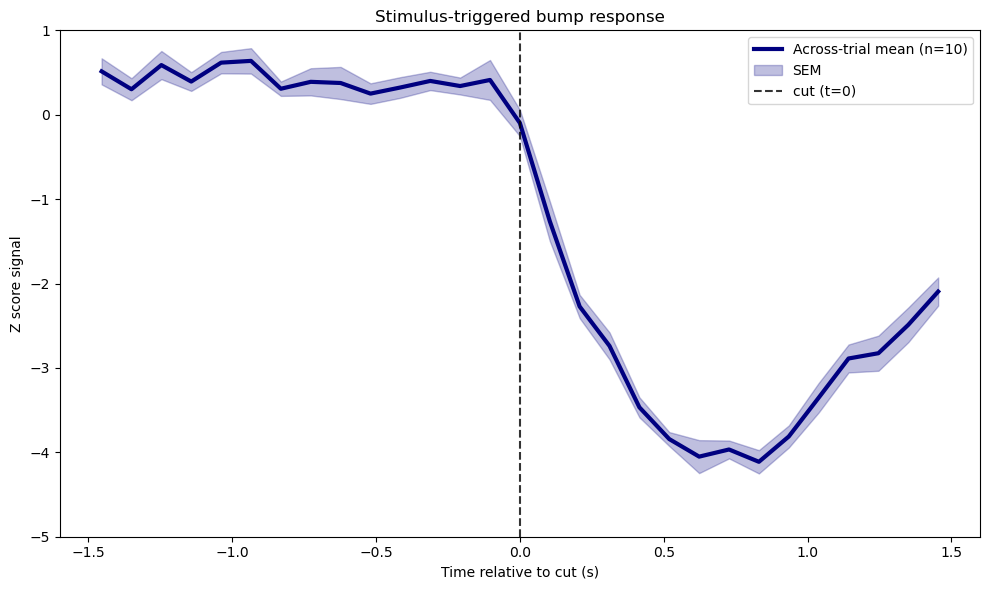

In [31]:
# Z_score_array: your 1D trace already plotted above
# cut_indices: the same indices you used for the shaded spans
# volume_time: seconds per frame (same you used earlier)
cuts_m1 = np.asarray(cut_indices, int)  -1  # center = cut-1


sta = compute_sta_around_cuts(
    signal=Z_score_array.squeeze(),
    cut_indices=cuts_m1,
    volume_time=volume_time,
    pre_s=1.5,
    post_s=1.5,
    align_to_next=True,   # aligns to (cut-1), matching your shading
    baseline=None         # or 'pre-sub' / 'pre-div' if you want baseline handling
)

plot_sta_simple(sta, title="Stimulus-triggered bump response", ylabel="Z score signal")


In [32]:
data_output = pd.DataFrame()
data_output['Time_Stamp'] = time_array_imaging
data_output['F_bg_subtracted'] = F_array_bg_subtracted[:,0]
data_output['F_data_background'] = F_array_background_stimulation_period_removed[:,0]
data_output['Raw_F_data'] = F_array_stimulation_period_removed [:,0]
data_output['Z_score_data'] = Z_score_array[:,0]
data_output['dFF_data'] = dF_F_array[:,0]

In [33]:
# Define file paths
output_file = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker/TQfly784-002.npz"
tif_file_path = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker/TQfly784/ROI_1_TQfly784-002.tif"  
tif_file_path_bg =  "/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker/TQfly784/ROI_1_TQfly784-002_background.tif" 
# Convert Pandas DataFrame to a dictionary of NumPy arrays
data_dict = {col: data_output[col].values for col in data_output.columns}

# Add the cut_indices array
data_dict["post_stim_frame"] = np.array(cut_indices)  # Ensure it's a NumPy array

# Read the TIFF file as a NumPy array
tif_image = tifffile.imread(tif_file_path)  # Load TIFF file
tif_image_bg = tifffile.imread(tif_file_path_bg)
# Add the TIFF image to the dictionary
data_dict["ROI_1"] = tif_image  # Store the TIFF as an array in the .npz file
data_dict["ROI_1_background"] = tif_image_bg
# Save everything in a .npz file
np.savez(output_file, **data_dict)

print(f"Data and TIFF image saved successfully as {output_file}")

Data and TIFF image saved successfully as /home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker/TQfly784-002.npz
